In [11]:
import os, re, pickle
import pandas as pd
import numpy as np
from scipy.stats import zscore
import seaborn as sns
from scipy.stats import pearsonr
import torch.nn.functional as F
import tensorflow_hub as hub 
from transformers import GPT2Tokenizer, GPT2LMHeadModel
base_path = 'C:/Users\hchen\Dropbox\PycharmProjects/false_mem'
SAVE_PATH = base_path+'/GPT_output/results_arrays/'

def check_correct(t, c):
    return np.nan if np.isnan(t) else (t == 1 and c == 0)
# Vectorize the function to apply it element-wise
vectorize_correct = np.vectorize(check_correct,otypes=[object])

def check_false(t, c):
    return np.nan if np.isnan(t) else (t == 0 or c == 1)
# Vectorize the function to apply it element-wise
vectorize_false = np.vectorize(check_false,otypes=[object])

# Correlating three semantic measures with false memory (confabulation or conflicts)

### loading memory performances for all 4 stories

In [12]:
THRESHOLD = 20 #number of recalls
story_ids = ['pieman','eyespy','oregontrail','baseball']
axis = 0  # 0=event, 1=subject
arr_perc_false = []
arr_perc_correct = []
arr_perc_conflict = []
arr_perc_overlap = []
arr_perc_confab = []
arr_perc_recall = []
keep_ids = []
for story_id in story_ids:
    recall_path = base_path+'/GPT_output/memory_classification/%s' % story_id
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('./A. script_prompting/story_segs.xlsx',
                           sheet_name='%s_segs' % story_id)['events'].to_list()

    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    id_path = 'C:/Users/hchen\Dropbox\PycharmProjects\speech2text_topic\data\integrated/all_first_two.xlsx'
    id_sheet = pd.read_excel(id_path)
    confab = np.load(SAVE_PATH+'/confab_%s.npy'%(story_id))
    true = np.load(SAVE_PATH+'/conflict_%s.npy'%(story_id))
    # percentage recall
    percent_recall = []
    for i in range(len(story_segs)):
        percent_recall.append((len(recall_paths)-np.sum(np.logical_or(np.isnan(confab[:,i]),np.isnan(true[:,i]))))/len(recall_paths))

    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    num_correct = np.nansum(correct,axis=axis)
    perc_correct = np.nansum(correct, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_conflict = np.nansum(true==0, axis=axis)
    perc_conflict = np.nansum(true==0, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_confab = np.nansum(confab==1, axis=axis)
    perc_confab = np.nansum(confab==1, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_false = np.nansum(false, axis=axis)
    perc_false = num_false/(np.array(percent_recall)*len(recall_paths))
    perc_overlap = perc_confab+perc_conflict-perc_false
    #
    """
    cleaning with threshold
    """
    keep_id = np.array(percent_recall)*len(recall_paths)>=THRESHOLD
    keep_ids.append(keep_id)
    print('removed event', len(percent_recall)-np.sum(keep_id))
    perc_false = perc_false[keep_id]
    perc_correct = perc_correct[keep_id]
    perc_conflict = perc_conflict[keep_id]
    perc_overlap = perc_overlap[keep_id]
    perc_confab = perc_confab[keep_id]
    percent_recall = np.array(percent_recall)[keep_id]
    
    arr_perc_false.append(perc_false)
    arr_perc_correct.append(perc_correct)
    arr_perc_conflict.append(perc_conflict)
    arr_perc_overlap.append(perc_overlap)
    arr_perc_confab.append(perc_confab)
    arr_perc_recall.append(percent_recall)

perc_false = np.concatenate(arr_perc_false)
perc_correct = np.concatenate(arr_perc_correct)
perc_conflict = np.concatenate(arr_perc_conflict)
perc_overlap = np.concatenate(arr_perc_overlap)
perc_confab = np.concatenate(arr_perc_confab)
perc_recall = np.concatenate(arr_perc_recall)
np.save(base_path+'/E. semantic_features/keep_ids', np.array(keep_ids, dtype=object), allow_pickle=True)


removed event 0
removed event 7
removed event 4
removed event 2


## 1. semantic centrality
models: USE, all-mpnet

In [18]:
from transformers import AutoTokenizer, AutoModel
from torch import Tensor
from sentence_transformers import SentenceTransformer
embedding_model = 'GIST'
def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]
def compute_cosine_similarity(embeddings):
    norm = np.linalg.norm(embeddings, axis=1)
    norm[norm == 0] = 1
    embeddings_normalized = embeddings / norm[:, np.newaxis]
    return np.dot(embeddings_normalized, embeddings_normalized.T)
def embed_model(embedding_model, txt):
    if embedding_model == 'USE':
        embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
        return embed(txt).numpy()
    elif embedding_model == 'GIST':
        model = SentenceTransformer("avsolatorio/GIST-Embedding-v0")
        return model.encode(txt)
    elif embedding_model == 'mpnet':
        model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
        return model.encode(txt)
    elif embedding_model == 'bge':
        model = SentenceTransformer('BAAI/bge-large-zh-v1.5')
        return model.encode(txt)
    elif embedding_model == 'e5':
        tokenizer = AutoTokenizer.from_pretrained('intfloat/e5-base-v2')
        model = AutoModel.from_pretrained('intfloat/e5-base-v2')
        batch_dict = tokenizer(list(txt), max_length=512, padding=True, truncation=True, return_tensors='pt')
        outputs = model(**batch_dict)
        embeddings = average_pool(outputs.last_hidden_state, batch_dict['attention_mask'])
        # F.normalize(embeddings, p=2, dim=1)
        return embeddings.detach().cpu().numpy()

In [19]:
centrality_arr = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()
    story_segs = np.array(story_segs)[keep_ids[j]]
    embedding = embed_model(embedding_model, story_segs)
    cos_sim = compute_cosine_similarity(embedding)
    n = cos_sim.shape[0]
    # Add nodes with initial centrality values
    np.fill_diagonal(cos_sim, np.nan)
    centrality=np.nanmean(cos_sim, axis=0)
    
    # centrality = np.load(base_path+'/E. semantic_features/centrality_mpnet_%s.npy' % story_id)
    norm_centrality = zscore(centrality)
    centrality_arr.extend(norm_centrality)
    
    np.save(base_path+'/E. semantic_features/centrality_%s_%s' % (embedding_model,story_id), centrality)

In [8]:
# find some examples
def true_position(keep_ids: list[list[bool]], i: int) -> tuple[int, int]:
    """
    Return (sublist_index, index_within_sublist) of the i-th True
    when sub-lists are viewed consecutively.

    Parameters
    ----------
    keep_ids : list[list[bool]]
        The Boolean sub-lists.
    i : int
        0-based index of the True you want
        (i = 0 → first True, i = 48 → 49th True, …).

    Raises
    ------
    IndexError if there are not enough True values.
    """
    remaining = i + 1          # convert 0-based index to 1-based count
    for sub_idx, sub in enumerate(keep_ids):
        cnt = sum(sub)         # number of Trues in this sub-list
        if remaining > cnt:    # skip whole sub-list
            remaining -= cnt
            continue

        # Target True is inside this sub-list
        true_seen = 0
        for local_idx, val in enumerate(sub):
            if val:
                if true_seen == remaining - 1:   # 0-based inside this sub
                    return sub_idx, local_idx
                true_seen += 1

    raise IndexError(f"Only {i} True values present – index {i} is out of range.")
# 
# ind = np.where((np.array(perc_recall)>0.6) & (np.array(centrality_arr)>1.3))[0]
# for i in ind:
#     a, b = true_position(keep_ids, i)
#     # event
#     story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
#                                    sheet_name='%s_segs' % story_ids[a])['events'].to_list()
#     print(story_ids[a], b, 'norm_centrality=',np.array(centrality_arr)[i],
#           'recall=',np.array(perc_recall)[i])
#     print(story_segs[b])
#     print('\n')

In [28]:
keep_ids

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False,  True, False,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True, False,  True,  True,
         True,  True,  True,  True, False,  True, False,  True, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True]),
 array([ True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True,

## 2. independent event "surprisal"


In [4]:
def score_gpt(sentence, tokenizer, model):
    tokenize_input = tokenizer.encode(sentence)
    tensor_input = torch.tensor([tokenize_input])
    loss=model(tensor_input, labels=tensor_input)[0]
    return loss.detach().numpy().mean()
model = GPT2LMHeadModel.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

Text(0.5, 1.0, 'Perplexity (PPL) distribution')

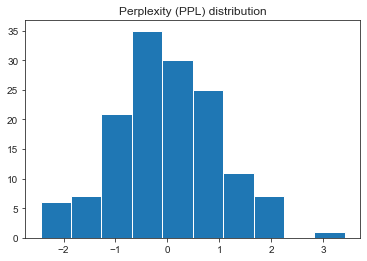

In [40]:
ppl = []
lengths = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    # story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
    #                            sheet_name='%s_segs' % story_id)['events'].to_list()
    # story_segs = np.array(story_segs)[keep_ids[j]]
    # ppl_story = []
    # for seg in story_segs:
    #     ppl_story.append(score_gpt(seg,tokenizer,model))
    # np.save(base_path+'/E. semantic_features/PPL_%s' % story_id, ppl_story)
    ppl_story = np.load(base_path+'/E. semantic_features/PPL_%s.npy' % story_id)
    ppl_story = zscore(ppl_story)
    ppl.extend(ppl_story)
    lengths.append(len(ppl_story))
plt.hist(ppl)
plt.title('Perplexity (PPL) distribution')

corr. coef = 0.20702318492480462, p = 0.013107066941789147


Text(0.5, 1.0, 'Correlation between sentence PPL and false memory')

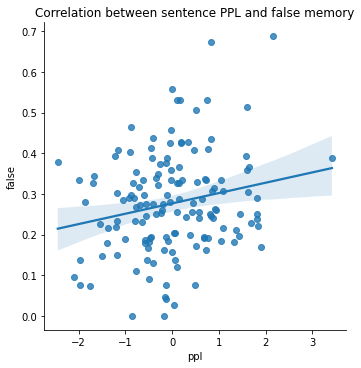

In [64]:
print('corr. coef = %s, p = %s' % pearsonr(ppl,perc_false))
sns.lmplot(x='ppl',y='false',data=pd.DataFrame(data=dict(ppl=ppl,false=perc_false)))
ax = plt.gca()
ax.set_title('Correlation between sentence PPL and false memory')

PearsonRResult(statistic=0.17612685370688705, pvalue=0.035364167115025)


Text(0.5, 1.0, 'Correlation between sentence ppl and confabulation')

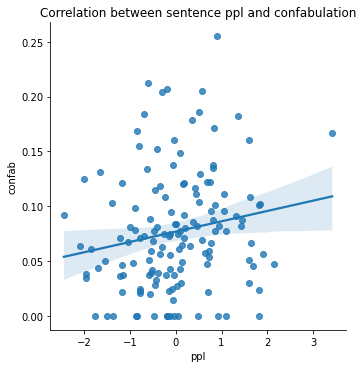

In [65]:
print(pearsonr(ppl,perc_confab))
sns.lmplot(x='ppl',y='confab',data=pd.DataFrame(data=dict(ppl=ppl,confab=perc_confab)))
ax = plt.gca()
ax.set_title('Correlation between sentence ppl and confabulation')

corr. coef = 0.1735012429095314, p = 0.0382367714191674


Text(0.5, 1.0, 'Correlation between ppl and conflict rate')

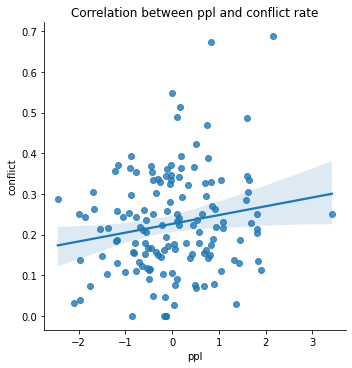

In [66]:
print('corr. coef = %s, p = %s' % pearsonr(ppl,perc_conflict))
sns.lmplot(x='ppl',y='conflict',data=pd.DataFrame(data=dict(ppl=ppl,conflict=perc_conflict)))
ax = plt.gca()
ax.set_title('Correlation between ppl and conflict rate')

corr. coef = -0.10155511298169297, p = 0.22747566632603342


Text(0.5, 1.0, 'Correlation between ppl and recall')

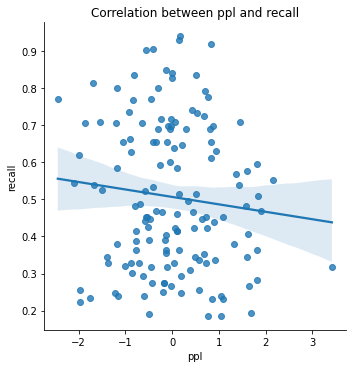

In [67]:
print('corr. coef = %s, p = %s' % pearsonr(ppl,perc_recall))
sns.lmplot(x='ppl',y='recall',data=pd.DataFrame(data=dict(ppl=ppl,recall=perc_recall)))
ax = plt.gca()
ax.set_title('Correlation between ppl and recall')

## 4. "Contextual" surprisal (main result)

In [49]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer, AutoTokenizer, OPTForCausalLM,AutoModelForCausalLM

def score_gpt_contextual(sentence, context, tokenizer, model, max_length=1024):    
    full_text = context + sentence
    tokenize_input = tokenizer.encode(full_text, return_tensors='pt')
    
    # Truncate the context if necessary
    if tokenize_input.size(1) > max_length:
        context_tokens = tokenizer.encode(context)
        sentence_tokens = tokenizer.encode(sentence)
        total_tokens = len(context_tokens) + len(sentence_tokens)
    
        if total_tokens > max_length:
            # Truncate the context
            truncated_context_tokens = context_tokens[-(max_length - len(sentence_tokens)):]
            tokenize_input = tokenizer.encode(truncated_context_tokens + sentence_tokens, return_tensors='pt')
        else:
            tokenize_input = tokenizer.encode(full_text, max_length=max_length, truncation=True, return_tensors='pt')
    
    # Tokenize only the sentence to create a mask
    sentence_tokens = tokenizer.encode(sentence, return_tensors='pt')
    
    # Create a mask for the loss calculation
    mask = torch.cat([torch.zeros(tokenize_input.size(1) - sentence_tokens.size(1)), torch.ones(sentence_tokens.size(1))])
    
    # Ensure tensor is on the same device as the model (e.g., GPU if available)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    tensor_input = tokenize_input.to(device)
    mask = mask.to(device)
    
    # Compute the loss
    with torch.no_grad():
        outputs = model(tensor_input, labels=tensor_input)
        loss = outputs[0]
    
    output = model(tensor_input, labels=tensor_input)
    logits = output.logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = tensor_input[..., 1:].contiguous()
    loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1), reduction='none')
    
    # Apply the mask to the loss
    masked_loss = loss * mask[1:]
    masked_loss = masked_loss.sum() / mask.sum()  # Average loss over the masked tokens
    return masked_loss.detach().cpu().numpy()
def score_pythia_contextual(sentence, context, tokenizer, model, max_length=1024):
    model.eval()

    # Tokenize without special tokens
    context_ids  = tokenizer.encode(context, add_special_tokens=False)
    sentence_ids = tokenizer.encode(sentence, add_special_tokens=False)

    # Truncate context to fit the sentence
    available = max_length - len(sentence_ids)
    if available < 0:
        # Sentence alone is too long
        sentence_ids = sentence_ids[-max_length:]
        context_ids = []
    else:
        # Keep last part of context
        context_ids = context_ids[-available:]

    # Build tensors
    input_ids = torch.tensor([context_ids + sentence_ids], dtype=torch.long)
    labels = input_ids.clone()
    labels[:, :len(context_ids)] = -100  # Ignore context in loss

    # Move to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    input_ids = input_ids.to(device)
    labels = labels.to(device)

    # Compute loss
    with torch.no_grad():
        loss = model(input_ids=input_ids, labels=labels).loss

    return float(loss.detach().cpu())
def score_opt_contextual(sentence, context, tokenizer, model, max_length=1024):
    # Make SDPA use eager kernels (avoids half-only attention paths)
    os.environ.setdefault("PYTORCH_FORCE_SDP_EAGER", "1")
    
    # --- tokenize to ID lists (no specials) ---
    ctx_ids  = tokenizer(context,  add_special_tokens=False).input_ids
    sent_ids = tokenizer(sentence, add_special_tokens=False).input_ids
    
    # --- build final ids, truncating ONLY context so sentence stays intact ---
    if len(ctx_ids) + len(sent_ids) > max_length:
        keep_ctx = max(0, max_length - len(sent_ids))
        ctx_ids = ctx_ids[-keep_ctx:]
    final_ids = ctx_ids + sent_ids
    
    # tensorize once
    tokenize_input = torch.tensor([final_ids], dtype=torch.long)  # <— was encode(...)
    
    # Tokenize-only sentence length (already have it)
    sentence_len = len(sent_ids)
    
    # Create a mask aligned to the final ids
    mask = torch.cat([
        torch.zeros(len(final_ids) - sentence_len, dtype=torch.float32),
        torch.ones(sentence_len, dtype=torch.float32)
    ])
    
    # Device + force fp32 everywhere
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device).eval()
    model.float()                                # <— harden against fp16 overflow
    tensor_input = tokenize_input.to(device)
    mask = mask.to(device)
    
    # Single forward pass; disable autocast; keep logits in fp32
    with torch.no_grad():
        if torch.cuda.is_available():
            ctx = torch.cuda.amp.autocast(enabled=False)
        else:
            class _Noop:
                def __enter__(self): pass
                def __exit__(self, *a): pass
            ctx = _Noop()
        with ctx:
            logits = model(input_ids=tensor_input).logits.float()
    
    # Standard causal shift
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = tensor_input[..., 1:].contiguous()
    
    # Per-token CE (no reduction)
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        reduction='none'
    ).view(shift_labels.size())
    
    # Align mask with prediction positions (drop first position)
    masked_loss = loss * mask[1:]
    masked_loss = masked_loss.sum() / mask.sum()   # avg over sentence tokens only
    
    # Return like your original (NumPy scalar)
    return masked_loss

In [48]:
ppl_contex = []
models = ['OPT']

for model_id in models:
    if model_id == 'gpt2':
        model = GPT2LMHeadModel.from_pretrained('gpt2')
        tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    elif model_id == 'pythia':
        MODEL_ID = "EleutherAI/pythia-160m-deduped"     # or "EleutherAI/pythia-70m
        tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, add_special_tokens=False)
        model     = AutoModelForCausalLM.from_pretrained(MODEL_ID)
        # Ensure pad token exists
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.pad_token_id
    elif model_id =='OPT':
        tokenizer = AutoTokenizer.from_pretrained("facebook/opt-125m")
        model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m")
    for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                                   sheet_name='%s_segs' % story_id)['events'].to_list()
        story_segs = np.array(story_segs)[keep_ids[j]]
        ppl_story = []
        context = ''
        for seg in story_segs:
            if model_id=='pythia':
                perplexity = score_pythia_contextual(seg, context, tokenizer, model)
            elif model_id=='OPT':
                perplexity = score_opt_contextual(seg, context, tokenizer, model)
            else:
                perplexity = score_gpt_contextual(seg, context, tokenizer, model)
            context = context+seg
            ppl_story.append(perplexity)
        np.save(base_path+'/E. semantic_features/PPL_context_%s_%s' % (model_id,story_id), ppl_story)
        # ppl_story = np.load(base_path+'/E. semantic_features/PPL_context_%s.npy' % story_id)
        # ppl_story = zscore(ppl_story)
        # ppl_contex.extend(ppl_story)
# plt.hist(ppl_contex)
# plt.title('Perplexity (PPL) distribution')

C:\Users\hchen\AppData\Local\Temp\ipykernel_29236\1232327891.py:117: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx = torch.cuda.amp.autocast(enabled=False)


RuntimeError: value cannot be converted to type at::Half without overflow

In [76]:
# remove the first event of each story
first_id = np.insert(np.cumsum(lengths)[0:-1],0,0)
ppl_contex2 =  [v for i, v in enumerate(ppl_contex) if i not in first_id]
perc_false2 = [v for i, v in enumerate(perc_false) if i not in first_id]
perc_confab2 = [v for i, v in enumerate(perc_confab) if i not in first_id]
perc_conflict2 = [v for i, v in enumerate(perc_conflict) if i not in first_id]
perc_recall2 = [v for i, v in enumerate(perc_recall) if i not in first_id]

corr. coef = 0.22294091020370588, p = 0.008339994933947244


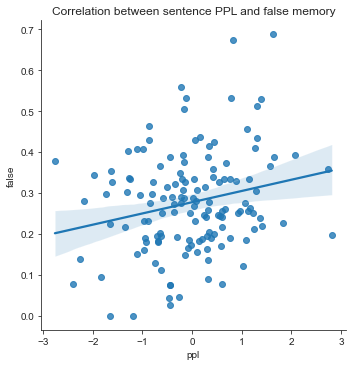

In [44]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
import matplotlib
matplotlib.rcParams.update(new_rc_params)
import matplotlib.pyplot as plt
print('corr. coef = %s, p = %s' % pearsonr(ppl_contex2,perc_false2))
sns.set_style("ticks")
sns.lmplot(x='ppl',y='false',data=pd.DataFrame(data=dict(ppl=ppl_contex2,false=perc_false2)))
ax = plt.gca()
ax.set_title('Correlation between sentence PPL and false memory')
plt.savefig('./PPL_false.svg')

In [1]:
pearsonr(perc_false, perc_recall)

NameError: name 'pearsonr' is not defined

PearsonRResult(statistic=0.23633785333011573, pvalue=0.005094220448774112)


Text(0.5, 1.0, 'Correlation between sentence ppl and confabulation')

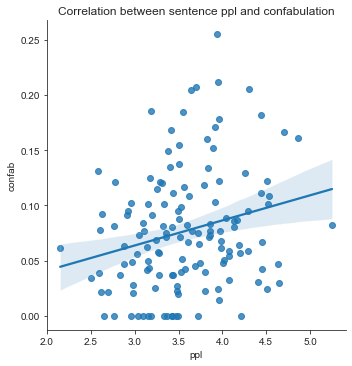

In [77]:
print(pearsonr(ppl_contex2,perc_confab2))
sns.lmplot(x='ppl',y='confab',data=pd.DataFrame(data=dict(ppl=ppl_contex2,confab=perc_confab2)))
ax = plt.gca()
ax.set_title('Correlation between sentence ppl and confabulation')

In [78]:
# find some examples
ind = np.where((np.array(perc_confab)>0.15) & (np.array(ppl_contex)>4))[0]
for i in ind:
    a, b = true_position(keep_ids, i)
    # event
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                                   sheet_name='%s_segs' % story_ids[a])['events'].to_list()
    print(story_ids[a], b, 'norm_PPL=',np.array(ppl_contex)[i],
          'confab=',np.array(perc_confab)[i])
    print(story_segs[b])
    print('\n')

eyespy 9 norm_PPL= 4.863832 confab= 0.16071428571428573
usually around mid morning the first sighting would be made usually by my aunt pat. she'd be ah they got rose out walking ethel looks drawn and then about an hour later my aunt gurt would say how old is rose now. and aunt momo would make the calculations. well let see jack died in sixty three when she was seventy four and rose birthday was two weeks last thursday and joe died in sixty nine making her a widow at eighty one so eighty five 


eyespy 11 norm_PPL= 4.302667 confab= 0.20512820512820512
hey who that who that who that. so they draw out the family tree in the sand they'd analyze it they'd come up with a profile and they'd crack the code it one of bobby. now any mention of bobby would always bring up the inevitable oh i just pray to god they don't tell poor senile rose about bobby it'll break her. 


eyespy 34 norm_PPL= 4.4375777 confab= 0.18181818181818182
and my aunt pat is hysterically screaming because that eyeball cost 

corr. coef = 0.1927198456432386, p = 0.023028181735241713


Text(0.5, 1.0, 'Correlation between ppl and conflict rate')

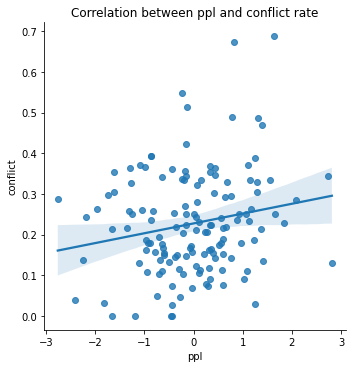

In [62]:
print('corr. coef = %s, p = %s' % pearsonr(ppl_contex2,perc_conflict2))
sns.lmplot(x='ppl',y='conflict',data=pd.DataFrame(data=dict(ppl=ppl_contex2,conflict=perc_conflict2)))
ax = plt.gca()
ax.set_title('Correlation between ppl and conflict rate')

corr. coef = -0.0182981783398889, p = 0.8307013672429175


Text(0.5, 1.0, 'Correlation between ppl and recall rate')

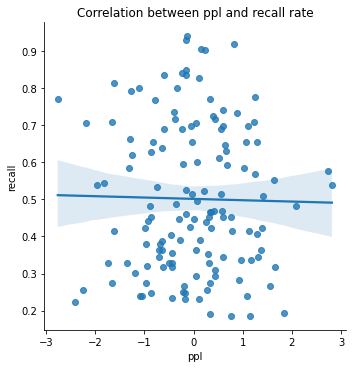

In [63]:
print('corr. coef = %s, p = %s' % pearsonr(ppl_contex2,perc_recall2))
sns.lmplot(x='ppl',y='recall',data=pd.DataFrame(data=dict(ppl=ppl_contex2,recall=perc_recall2)))
ax = plt.gca()
ax.set_title('Correlation between ppl and recall rate')

## Contextual entropy (renyi entropy with alpha=1/2)

https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00603/118720

In [3]:
def renyi_entropy_contextual(sentence,
                             context,
                             tokenizer,
                             model,
                             alpha: float = 1.0,
                             max_length: int = 1024,
                             eps: float = 1e-12):
    """
    Return the Rényi entropy H_alpha(p) of GPT‑2's next‑token distribution
    given *context*.

    Parameters
    ----------
    sentence : str
        Unused; kept for signature compatibility with `score_gpt_contextual`.
    context : str
        The textual context conditioning the model.
    tokenizer : transformers.PreTrainedTokenizer
    model : transformers.PreTrainedModel
    alpha : float, optional
        Rényi order. alpha=1.0 yields Shannon entropy.
    max_length : int, optional
        Maximum tokens to feed into the model (GPT‑2 limit is 1024).
    eps : float, optional
        Numerical stabiliser to avoid log(0).

    Returns
    -------
    float
        Rényi (or Shannon) entropy in nats.
    """
    # --- Encode only the context -------------------------------------------
    context_ids = tokenizer.encode(context, return_tensors='pt')
    if context_ids.size(1) > max_length:
        context_ids = context_ids[:, -max_length:]

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    context_ids = context_ids.to(device)

    # --- Forward pass (no gradients needed) --------------------------------
    with torch.no_grad():
        logits = model(context_ids).logits           # [1, seq_len, vocab]
        next_logits = logits[0, -1]                  # last position
        probs = torch.softmax(next_logits, dim=-1)   # p(vocab)

    # --- Compute Rényi / Shannon entropy -----------------------------------
    if alpha == 1.0:
        entropy = -(probs * torch.log(probs + eps)).sum()
    else:
        entropy = torch.log((probs ** alpha).sum() + eps) / (1.0 - alpha)

    return entropy.item()


In [16]:
model = GPT2LMHeadModel.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

entropy_all = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    # story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx', sheet_name='%s_segs' % story_id)['events'].to_list()
    # story_segs = np.array(story_segs)[keep_ids[j]]
    # entropy = []
    # context = ''
    # for seg in story_segs:
    #     context = context+seg
    #     ent = renyi_entropy_contextual(seg, context, tokenizer, model, alpha=1/2)
    #     entropy.append(ent)
    # np.save(base_path+'/E. semantic_features/renyi_entropy_%s' % story_id, entropy)
    entropy_story = np.load(base_path+'/E. semantic_features/renyi_entropy_%s.npy' % story_id)
    # entropy_story = zscore(entropy_story)
    entropy_all.extend(entropy_story)

Text(0.5, 1.0, 'entropy distribution')

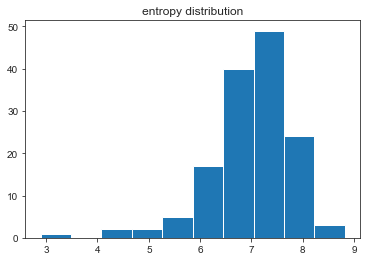

In [17]:
plt.hist(entropy_all)
plt.title('entropy distribution')

corr. coef = -0.15712603695753985, p = 0.060913632706819994


Text(0.5, 1.0, 'Correlation between entropy and false memory')

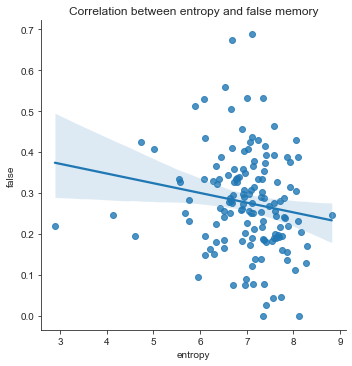

In [18]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
import matplotlib
matplotlib.rcParams.update(new_rc_params)
import matplotlib.pyplot as plt
print('corr. coef = %s, p = %s' % pearsonr(entropy_all,perc_false))
sns.set_style("ticks")
sns.lmplot(x='entropy',y='false',data=pd.DataFrame(data=dict(entropy=entropy_all,false=perc_false)))
ax = plt.gca()
ax.set_title('Correlation between entropy and false memory')

corr. coef = -0.19297587188721727, p = 0.020935178899477862


Text(0.5, 1.0, 'Correlation between entropy and conflict rate')

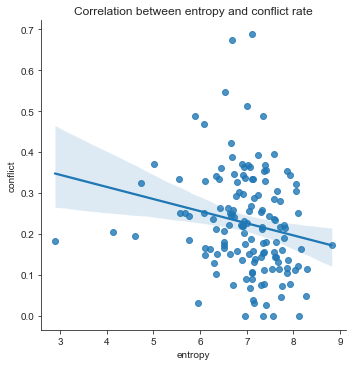

In [21]:
print('corr. coef = %s, p = %s' % pearsonr(entropy_all,perc_conflict))
sns.lmplot(x='entropy',y='conflict',data=pd.DataFrame(data=dict(entropy=entropy_all,conflict=perc_conflict)))
ax = plt.gca()
ax.set_title('Correlation between entropy and conflict rate')

# split the stories

In [68]:
for feature in ['centrality_','PPL_','PPL_context_']:
    print(feature)
    for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        feature_vec = np.load(base_path+'/E. semantic_features/'+feature+'%s' % story_id+'.npy')
        feature_vec = zscore(feature_vec)
        print(story_id)
        if 'PPL_context_' in feature:
            print('recall corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec[1:],arr_perc_recall[j][1:]))
            print('false corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec[1:],arr_perc_false[j][1:]))
            print('conflict corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec[1:],arr_perc_conflict[j][1:]))
            print('confab corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec[1:],arr_perc_confab[j][1:]))
        else:
            print('recall corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec,arr_perc_recall[j]))
            print('false corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec,arr_perc_false[j]))
            print('conflict corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec,arr_perc_conflict[j]))
            print('confab corr. coef = %.2f, p = %.3f' % pearsonr(feature_vec,arr_perc_confab[j]))
    print('\n\n')
    

centrality_
pieman
recall corr. coef = 0.37, p = 0.076
false corr. coef = 0.19, p = 0.382
conflict corr. coef = 0.18, p = 0.406
confab corr. coef = 0.13, p = 0.554
eyespy
recall corr. coef = 0.36, p = 0.025
false corr. coef = 0.03, p = 0.843
conflict corr. coef = -0.14, p = 0.392
confab corr. coef = 0.37, p = 0.022
oregontrail
recall corr. coef = 0.19, p = 0.224
false corr. coef = -0.24, p = 0.115
conflict corr. coef = -0.24, p = 0.116
confab corr. coef = -0.26, p = 0.095
baseball
recall corr. coef = 0.13, p = 0.433
false corr. coef = -0.01, p = 0.969
conflict corr. coef = -0.04, p = 0.810
confab corr. coef = 0.21, p = 0.206



PPL_
pieman
recall corr. coef = 0.04, p = 0.846
false corr. coef = 0.39, p = 0.058
conflict corr. coef = 0.30, p = 0.150
confab corr. coef = 0.46, p = 0.023
eyespy
recall corr. coef = 0.02, p = 0.918
false corr. coef = 0.40, p = 0.013
conflict corr. coef = 0.37, p = 0.020
confab corr. coef = 0.10, p = 0.540
oregontrail
recall corr. coef = -0.33, p = 0.029
false 

## correlating centrality and surprisal

In [6]:
features = [[],[]]
for i, feature in enumerate(['centrality_','PPL_context_']):
    for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
        feature_vec = np.load(base_path+'/E. semantic_features/'+feature+'%s' % story_id+'.npy')
        feature_vec = zscore(feature_vec)
        features[i].extend(feature_vec)

corr. coef = -0.11421454797865263, p = 0.1743782268760208


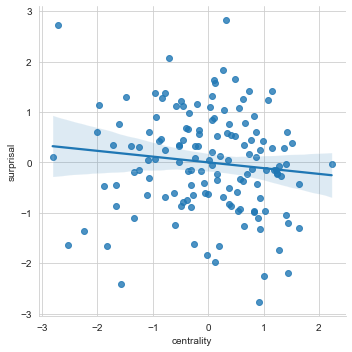

In [7]:
print('corr. coef = %s, p = %s' % pearsonr(features[0],features[1]))
sns.lmplot(x='centrality',y='surprisal',data=pd.DataFrame(data=dict(centrality=features[0],surprisal=features[1])))

# 5. Prior knowledge

Text(0.5, 1.0, 'similarity to prior knoweldge distribution')

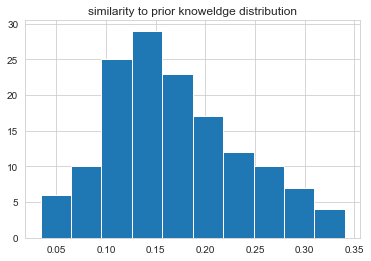

In [4]:
with open(base_path+'/E. semantic_features/PriorKnowledge_allstories_mpnet.pkl', 'rb') as file:
        pickled_prior=pickle.load(file)
prior = []
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    prior_story = pickled_prior[j]
    # prior_story = zscore(prior_story)
    prior.extend(prior_story)
plt.hist(prior)
plt.title('similarity to prior knoweldge distribution')

PearsonRResult(statistic=0.2178055369600898, pvalue=0.008970765238425708)


Text(0.5, 1.0, 'Correlation between simlarity to prior corpus and false memory')

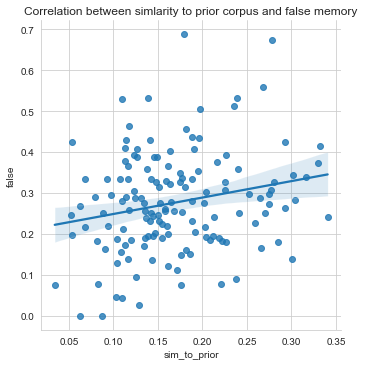

In [5]:
print(pearsonr(prior,perc_false))
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}

sns.lmplot(x='sim_to_prior',y='false',data=pd.DataFrame(data=dict(sim_to_prior=prior,false=perc_false)))
ax = plt.gca()
ax.set_title('Correlation between simlarity to prior corpus and false memory')


PearsonRResult(statistic=0.27650627084077317, pvalue=0.0008289720849790229)


Text(0.5, 1.0, 'Correlation between simlarity to prior corpus and conflict')

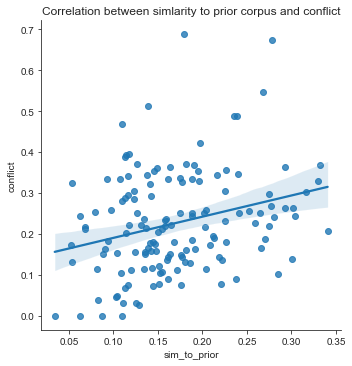

In [66]:
print(pearsonr(prior,perc_conflict))
sns.lmplot(x='sim_to_prior',y='conflict',data=pd.DataFrame(data=dict(sim_to_prior=prior,conflict=perc_conflict)))
ax = plt.gca()
ax.set_title('Correlation between simlarity to prior corpus and conflict')


In [11]:
# find some examples
ind = np.where((np.array(prior)>0.2) )[0]
for i in ind:
    a, b = true_position(keep_ids, i)
    # event
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                                   sheet_name='%s_segs' % story_ids[a])['events'].to_list()
    print(story_ids[a], b, 'prior=',np.array(prior)[i],
          'conflict=',np.array(perc_conflict)[i])
    print(story_segs[b])
    print('\n')

pieman 9 prior= 0.23744571683715313 conflict= 0.09090909090909091
And said that as he fled the scene, he clicked his heels in rakish glee. And I gave him a catchphrase in Latin. 


pieman 10 prior= 0.26440600182592766 conflict= 0.25
I said that he cried out, “Ego sum non an bestia,” which means “I am not an animal.” Which makes no sense. I needed something. I’m Catholic, Latin just comes to me. So I finish my story and I hand it to Dwyer. 


pieman 16 prior= 0.22220062575339042 conflict= 0.13636363636363635
crying, “Ego sum non an bestia.” Or at least that’s what it said in my story in the newspaper the next day, which ran with a photo of him leaving the scene, cape flowing behind him, doing this. 


pieman 18 prior= 0.20167068257931373 conflict= 0.25
And toward the end of this run, I was out at a bar one night, and I saw, I came and I saw in the corner Angela from my Brit Lit class, drinking with some friends. 


pieman 22 prior= 0.20881716565086422 conflict= 0.1728395061728395
And wa

PearsonRResult(statistic=-0.0290063843750689, pvalue=0.7309260203722245)


Text(0.5, 1.0, 'Correlation between simlarity to prior corpus and confabulation')

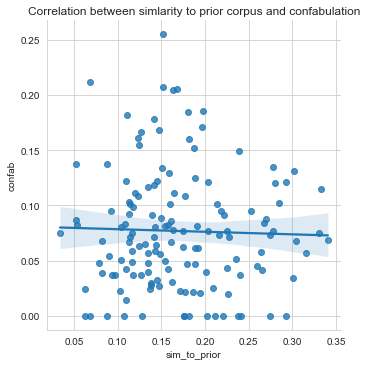

In [15]:
print(pearsonr(prior,perc_confab))
sns.lmplot(x='sim_to_prior',y='confab',data=pd.DataFrame(data=dict(sim_to_prior=prior,confab=perc_confab)))
ax = plt.gca()
ax.set_title('Correlation between simlarity to prior corpus and confabulation')


PearsonRResult(statistic=0.00031168738182772455, pvalue=0.9970522011705393)


Text(0.5, 1.0, 'Correlation between simlarity to prior corpus and recall')

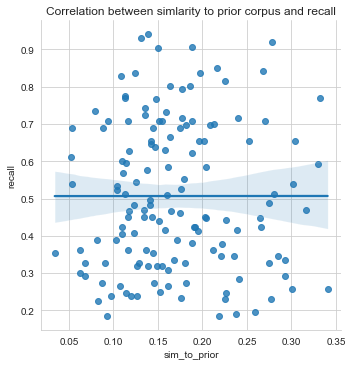

In [16]:
print(pearsonr(prior,perc_recall))
sns.lmplot(x='sim_to_prior',y='recall',data=pd.DataFrame(data=dict(sim_to_prior=prior,recall=perc_recall)))
ax = plt.gca()
ax.set_title('Correlation between simlarity to prior corpus and recall')
